# Sampling Method Comparison

In [29]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.spatial.distance import cdist

## Constants

In [30]:
N_SAMPLES  = 64      # Number of sample points
N_DIMS     = 4        # Number of design variables (W1, W2, R, t)
N_REPEATS  = 50       # Number of realisations for random sampling and LHS
SEED_BASE  = 42       # Base random seed for reproducibility

## Evaluation Metrics

In [ ]:
# Compute eval methods
# AMD = Average Euclidean distance to nearest neighbour (higher = better space-filling)
def average_minimum_distance(samples):
    dist_matrix = cdist(samples, samples) # Pairwise distance matrix
    np.fill_diagonal(dist_matrix, np.inf) # Exclude self-distances
    min_dists = np.min(dist_matrix, axis=1) # Nearest neighbour distance per point
    return np.mean(min_dists) # Average of nearest neighbour distances

# Discrepancy = L2* Star Discrepancy (lower = better uniformity)
def l2_star_discrepancy(samples):
    return qmc.discrepancy(samples, method='L2-star')

## Sampling Methods

In [32]:
# Sampling methods
# Random Sampling: Uniform random sampling within the unit hypercube.
def random_sampling(n_samples, n_dims, seed):
    rng = np.random.default_rng(seed)
    return rng.random((n_samples, n_dims))

# Sobol Sequence: A low-discrepancy sequence that fills the space more uniformly than random sampling.
def sobol_sampling(n_samples, n_dims):
    sampler = qmc.Sobol(d=n_dims)
    return sampler.random(n_samples)

# Latin Hypercube Sampling (LHS): A stratified sampling method that ensures each dimension is sampled uniformly.
def lhs_sampling(n_samples, n_dims, seed):
    sampler = qmc.LatinHypercube(d=n_dims, seed=seed)
    return sampler.random(n_samples)

## Generate samples and evaluate

### Random Sampling

In [ ]:
random_amd  = [] # Average Minimum Distance for random sampling
random_disc = [] # Discrepancy for random sampling

# Loop over multiple realisations of random sampling to compute statistics
for i in range(N_REPEATS):
    samples = random_sampling(N_SAMPLES, N_DIMS, seed=SEED_BASE + i) # Different seed for each realisation
    random_amd.append(average_minimum_distance(samples)) # Compute AMD for this realisation
    random_disc.append(l2_star_discrepancy(samples)) # Compute Discrepancy for this realisation

# Calculate mean and standard deviation for random sampling metrics
random_amd_mean  = np.mean(random_amd) # Average AMD across realisations
random_amd_std   = np.std(random_amd) # Standard deviation of AMD across realisations
random_disc_mean = np.mean(random_disc) # Average Discrepancy across realisations
random_disc_std  = np.std(random_disc) # Standard deviation of Discrepancy across realisations

# Print results
print(f"\nRandom Sampling ({N_REPEATS} realisations):")
print(f"  AMD:          {random_amd_mean:.4f} ± {random_amd_std:.4f}")
print(f"  Discrepancy:  {random_disc_mean:.4f} ± {random_disc_std:.4f}")


Random Sampling (50 realisations):
  AMD:          0.2396 ± 0.0111
  Discrepancy:  0.0278 ± 0.0065


### Sobol Sampling

In [34]:
sobol_samples   = sobol_sampling(N_SAMPLES, N_DIMS) # No seed needed for deterministic Sobol sequence
sobol_amd       = average_minimum_distance(sobol_samples) # AMD for Sobol sequence
sobol_disc      = l2_star_discrepancy(sobol_samples) # Discrepancy for Sobol sequence

# Print results
# WARNING: Sobol requires N_SAMPLES to be a power of 2 for accurate evaluation. If not, results may be misleading.
print(f"\nSobol Sequence:")
print(f"  AMD:          {sobol_amd:.4f}")
print(f"  Discrepancy:  {sobol_disc:.4f}")



Sobol Sequence:
  AMD:          0.2891
  Discrepancy:  0.0127


### LHS

In [ ]:
lhs_amd  = [] # Average Minimum Distance for LHS
lhs_disc = [] # Discrepancy for LHS

# Loop over multiple realisations of LHS to compute statistics (LHS is stochastic due to random seed)
for i in range(N_REPEATS):
    samples = lhs_sampling(N_SAMPLES, N_DIMS, seed=SEED_BASE + i) # Different seed for each realisation
    lhs_amd.append(average_minimum_distance(samples)) # Compute AMD for this realisation
    lhs_disc.append(l2_star_discrepancy(samples)) # Compute Discrepancy for this realisation

lhs_amd_mean  = np.mean(lhs_amd) # Average Minimum Distance for LHS
lhs_amd_std   = np.std(lhs_amd) # Standard deviation of AMD for LHS
lhs_disc_mean = np.mean(lhs_disc) # Average Discrepancy for LHS
lhs_disc_std  = np.std(lhs_disc) # Standard deviation of Discrepancy for LHS

# Print results
print(f"\nLHS ({N_REPEATS} realisations):")
print(f"  AMD:          {lhs_amd_mean:.4f} ± {lhs_amd_std:.4f}")
print(f"  Discrepancy:  {lhs_disc_mean:.4f} ± {lhs_disc_std:.4f}")


LHS (50 realisations):
  AMD:          0.2525 ± 0.0096
  Discrepancy:  0.0189 ± 0.0025


## Visualise results

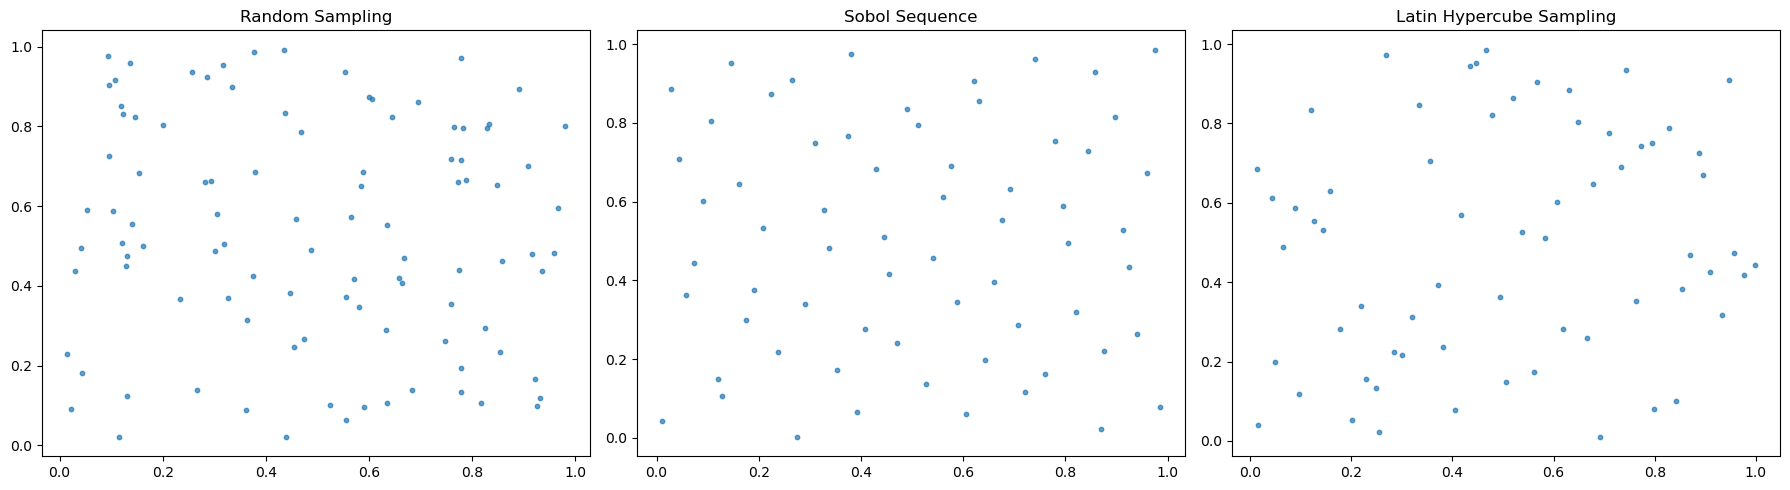

In [36]:
# Visualise the scatter plots for each method (only first 2 dimensions for clarity)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(random_pts[:, 0], random_pts[:, 1], s=10, alpha=0.7)
axes[0].set_title("Random Sampling")
axes[1].scatter(sobol_samples[:, 0], sobol_samples[:, 1], s=10, alpha=0.7)
axes[1].set_title("Sobol Sequence")
lhs_pts = lhs_sampling(N_SAMPLES, N_DIMS, seed=SEED_BASE) # Generate one LHS sample for visualization
axes[2].scatter(lhs_pts[:, 0], lhs_pts[:, 1], s=10, alpha=0.7)
axes[2].set_title("Latin Hypercube Sampling")
plt.tight_layout()
plt.show()